# Hospital Readmission Prediction - Data Exploration

This notebook loads the UCI diabetes readmission dataset, performs data cleaning, creates an initial exploratory analysis, and saves the plots to the results folder.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')

project_root = Path.cwd().resolve().parent if 'notebooks' in str(Path.cwd()) else Path.cwd().resolve()
DATA_PATH = project_root / 'diabetes+130-us+hospitals+for+years+1999-2008' / 'diabetic_data.csv'
FIGURES_DIR = project_root / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Loading dataset...')
df = pd.read_csv(DATA_PATH)
df = df.replace('?', np.nan)

print('Shape:', df.shape)
print('\nData types:')
print(df.dtypes)
print('\nFirst 5 rows:')
print(df.head().to_string())

Loading dataset...


Shape: (101766, 50)

Data types:
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide        

## Missing-value audit

This section reports the percentage of missing values per column and highlights the most incomplete fields.

In [2]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_df = missing_pct.reset_index()
missing_df.columns = ['column', 'missing_pct']
print('Missing-value audit (top columns):')
print(missing_df.head(20).to_string(index=False))
missing_df.to_csv(FIGURES_DIR / 'missing_value_audit.csv', index=False)

Missing-value audit (top columns):
                  column  missing_pct
                  weight    96.858479
           max_glu_serum    94.746772
               A1Cresult    83.277322
       medical_specialty    49.082208
              payer_code    39.557416
                    race     2.233555
                  diag_3     1.398306
                  diag_2     0.351787
                  diag_1     0.020636
             patient_nbr     0.000000
        time_in_hospital     0.000000
     admission_source_id     0.000000
      num_lab_procedures     0.000000
            encounter_id     0.000000
       admission_type_id     0.000000
discharge_disposition_id     0.000000
                  gender     0.000000
                     age     0.000000
        number_inpatient     0.000000
        number_emergency     0.000000


## Target preparation

The original target variable is converted into a binary label for 30-day readmission analysis.

In [3]:
df['readmitted_30'] = df['readmitted'].apply(lambda x: 1 if str(x).strip() == '<30' else 0)

class_balance = df['readmitted_30'].value_counts(dropna=False)
class_balance_pct = df['readmitted_30'].value_counts(normalize=True).mul(100).round(2)
print('Class balance (counts):')
print(class_balance)
print('\nClass balance (percent):')
print(class_balance_pct)

ratio = class_balance[0] / class_balance[1]
print(f'\nImbalance ratio (majority:minority) = {ratio:.2f} : 1')

Class balance (counts):
readmitted_30
0    90409
1    11357
Name: count, dtype: int64

Class balance (percent):
readmitted_30
0    88.84
1    11.16
Name: proportion, dtype: float64

Imbalance ratio (majority:minority) = 7.96 : 1


## Class-balance plot

Interpretation: The class balance is strongly skewed, with 90,409 non-readmitted and 11,357 readmitted cases, giving an imbalance ratio of about 7.96:1. That means accuracy is a misleading headline metric, and Stage 2 should rely on precision, recall, ROC-AUC, and either resampling or class weighting.

C:\Users\sagir\AppData\Local\Temp\ipykernel_20264\259543145.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='readmitted_30', palette='Set2')


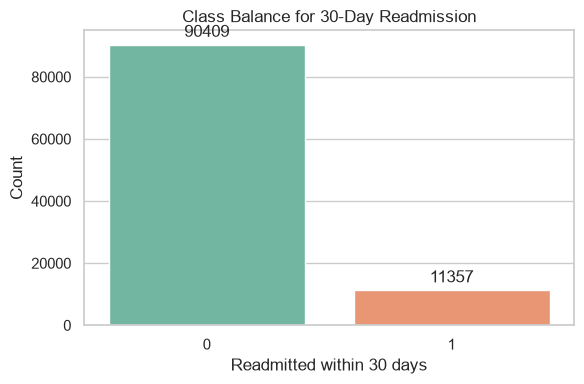

In [4]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='readmitted_30', palette='Set2')
ax.set_title('Class Balance for 30-Day Readmission')
ax.set_xlabel('Readmitted within 30 days')
ax.set_ylabel('Count')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_balance.png', dpi=300)
plt.show()

In [5]:
if 'class_balance' not in globals():
    class_balance = df['readmitted_30'].value_counts(dropna=False)
ratio = class_balance[0] / class_balance[1]
print(f'Imbalance ratio (majority:minority) = {ratio:.2f} : 1')

Imbalance ratio (majority:minority) = 7.96 : 1


## Feature distributions

Interpretation: The selected distributions show clear skew and missingness patterns. Age is the clearest categorical signal, with older groups showing readmission rates around 12% to 14% while the 0–10 group is below 2%. The most problematic fields are weight, max_glu_serum, and A1Cresult, which are missing in roughly 83% to 97% of rows and are better handled as missingness flags or dropped rather than imputed.

C:\Users\sagir\AppData\Local\Temp\ipykernel_20264\1968360621.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str), y=counts.values, palette='Set2')


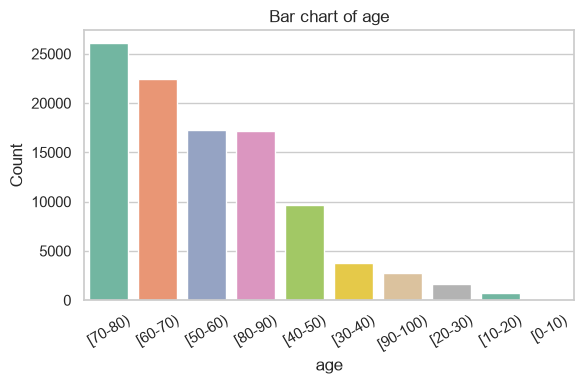

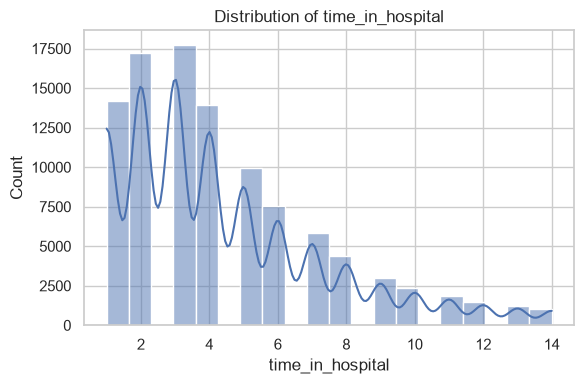

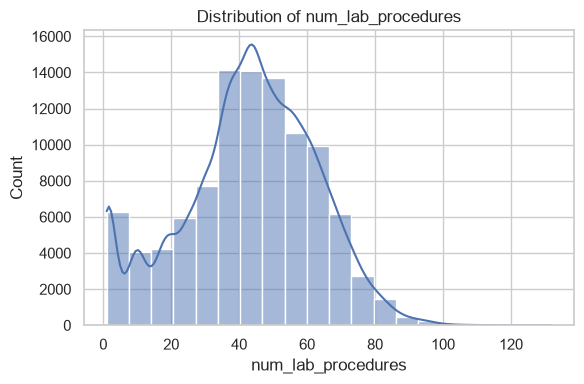

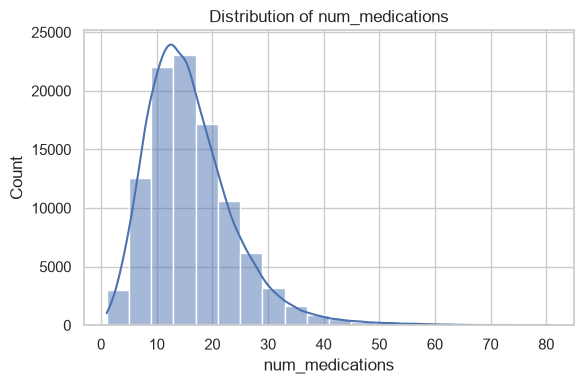

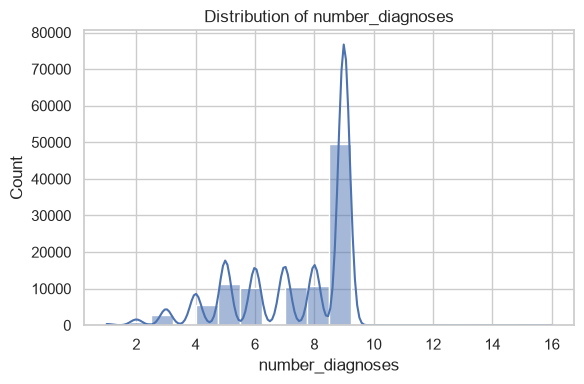

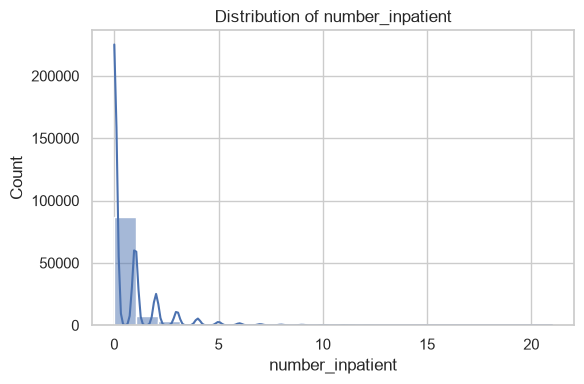

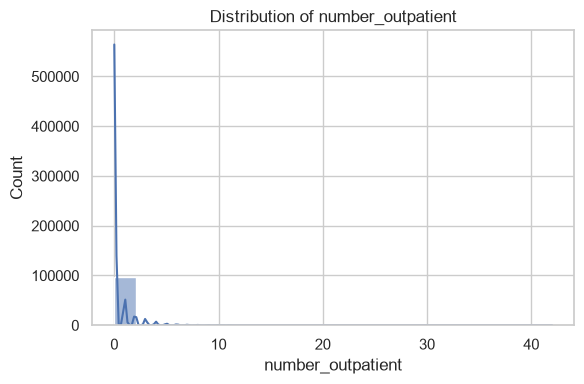

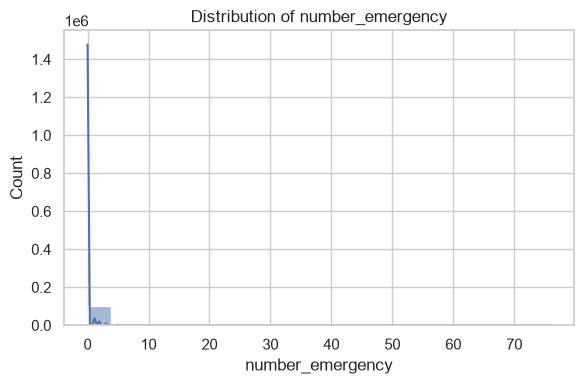

C:\Users\sagir\AppData\Local\Temp\ipykernel_20264\1968360621.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str), y=counts.values, palette='Set2')


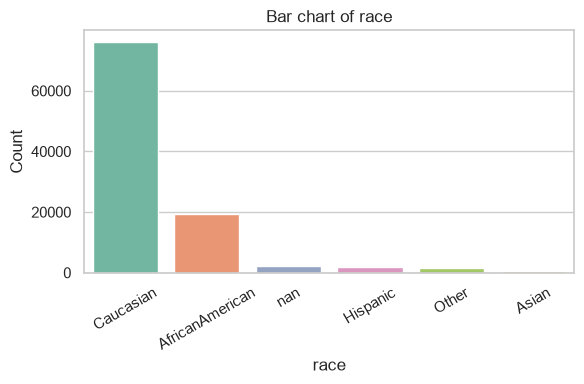

C:\Users\sagir\AppData\Local\Temp\ipykernel_20264\1968360621.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str), y=counts.values, palette='Set2')


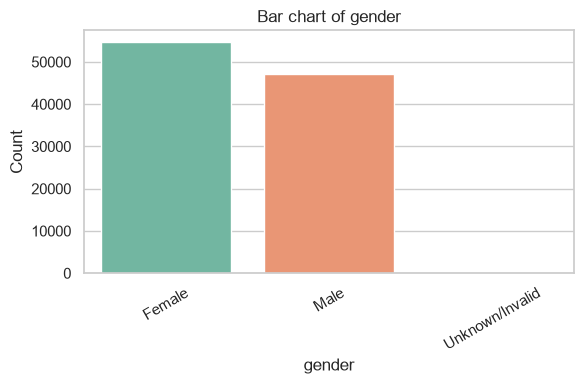

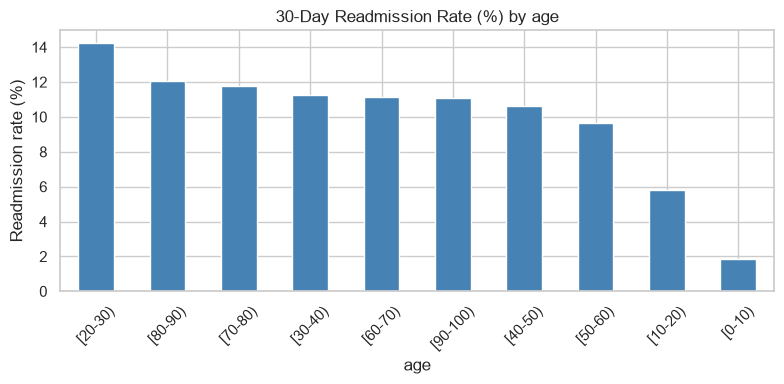


Readmission rate by age:
age
[20-30)     14.242607
[80-90)     12.083503
[70-80)     11.773055
[30-40)     11.231788
[60-70)     11.128408
[90-100)    11.099177
[40-50)     10.604027
[50-60)      9.666203
[10-20)      5.788712
[0-10)       1.863354
Name: readmitted_30, dtype: float64


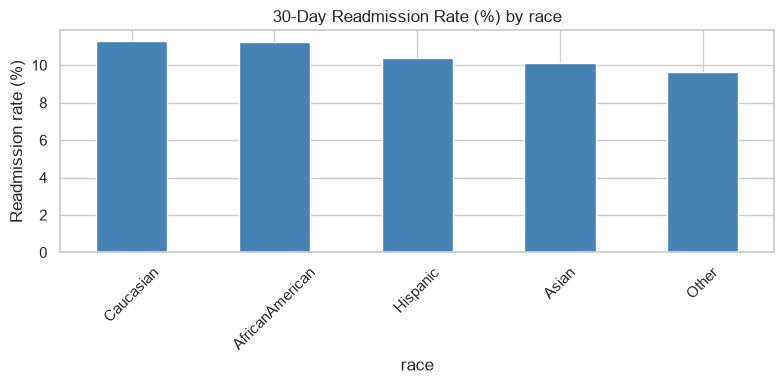


Readmission rate by race:
race
Caucasian          11.290556
AfricanAmerican    11.218116
Hispanic           10.407462
Asian              10.140406
Other               9.628154
Name: readmitted_30, dtype: float64


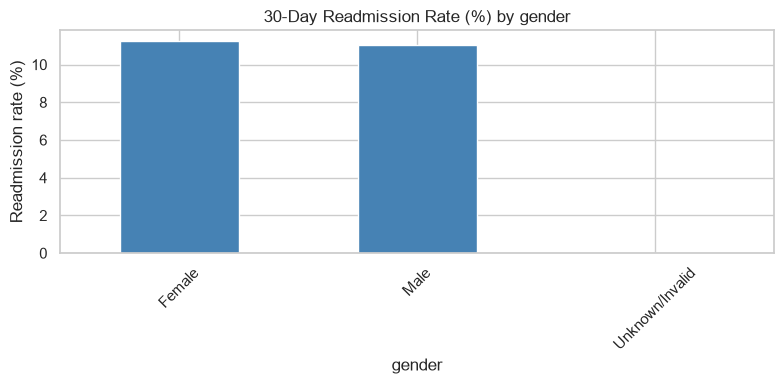


Readmission rate by gender:
gender
Female             11.245156
Male               11.061524
Unknown/Invalid     0.000000
Name: readmitted_30, dtype: float64


In [6]:
selected_features = [
    'age', 'time_in_hospital', 'num_lab_procedures', 'num_medications',
    'number_diagnoses', 'number_inpatient', 'number_outpatient',
    'number_emergency', 'race', 'gender'
]

for feature in selected_features:
    if feature in df.columns:
        if pd.api.types.is_numeric_dtype(df[feature]):
            plt.figure(figsize=(6, 4))
            sns.histplot(df[feature].dropna(), kde=True, bins=20)
            plt.title(f'Distribution of {feature}')
            plt.xlabel(feature)
            plt.ylabel('Count')
            plt.tight_layout()
            plt.savefig(FIGURES_DIR / f'{feature}_distribution.png', dpi=300)
            plt.show()
        else:
            plt.figure(figsize=(6, 4))
            counts = df[feature].value_counts(dropna=False).head(10)
            sns.barplot(x=counts.index.astype(str), y=counts.values, palette='Set2')
            plt.title(f'Bar chart of {feature}')
            plt.xlabel(feature)
            plt.ylabel('Count')
            plt.xticks(rotation=30)
            plt.tight_layout()
            plt.savefig(FIGURES_DIR / f'{feature}_distribution.png', dpi=300)
            plt.show()

for cat_feature in ['age', 'race', 'gender']:
    if cat_feature in df.columns:
        rate = df.groupby(cat_feature)['readmitted_30'].mean().mul(100).sort_values(ascending=False)
        plt.figure(figsize=(8, 4))
        rate.plot(kind='bar', color='steelblue')
        plt.title(f'30-Day Readmission Rate (%) by {cat_feature}')
        plt.ylabel('Readmission rate (%)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f'readmit_rate_by_{cat_feature}.png', dpi=300)
        plt.show()
        print(f'\nReadmission rate by {cat_feature}:')
        print(rate)

## Compact coverage of all remaining raw features

The detailed plots above cover 10 clinically selected features. The grids below cover every other raw dataset column except `encounter_id` and `patient_nbr`. Those two identifier fields are intentionally excluded because their arbitrary values are not clinically interpretable distributions and should not be used as predictive features; `patient_nbr` is instead used to enforce patient-grouped splitting.

The remaining medication fields are highly imbalanced, with many dominated by a single `No` category; several are therefore near-zero-variance candidates for consolidation. Diagnosis-code fields are unusually high-cardinality, so their panels display only the ten most common observed codes rather than attempting to label every code.

Raw columns: 50
Detailed individual plots: 10
Identifier columns excluded from visualization: ['encounter_id', 'patient_nbr']
Numeric compact-grid columns (4): ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'num_procedures']
Categorical compact-grid columns (34): ['weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


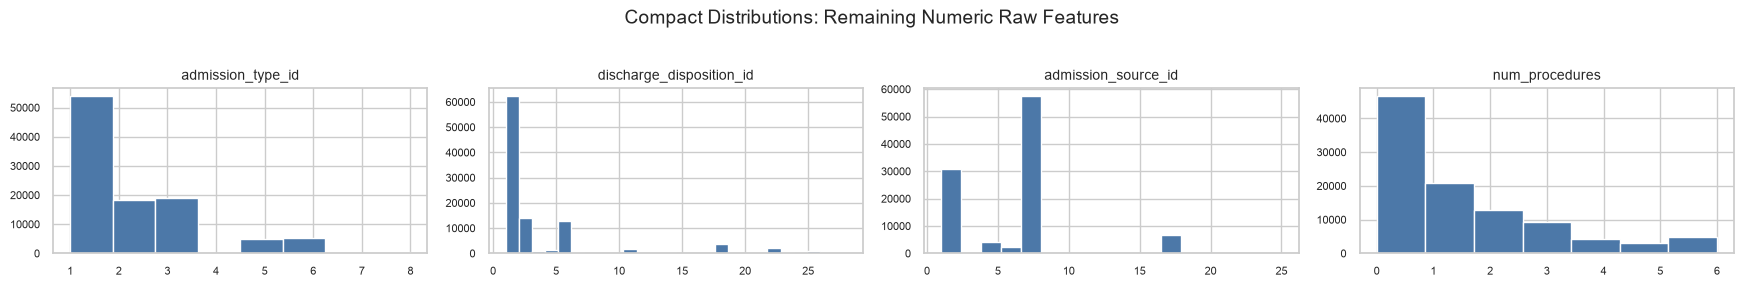

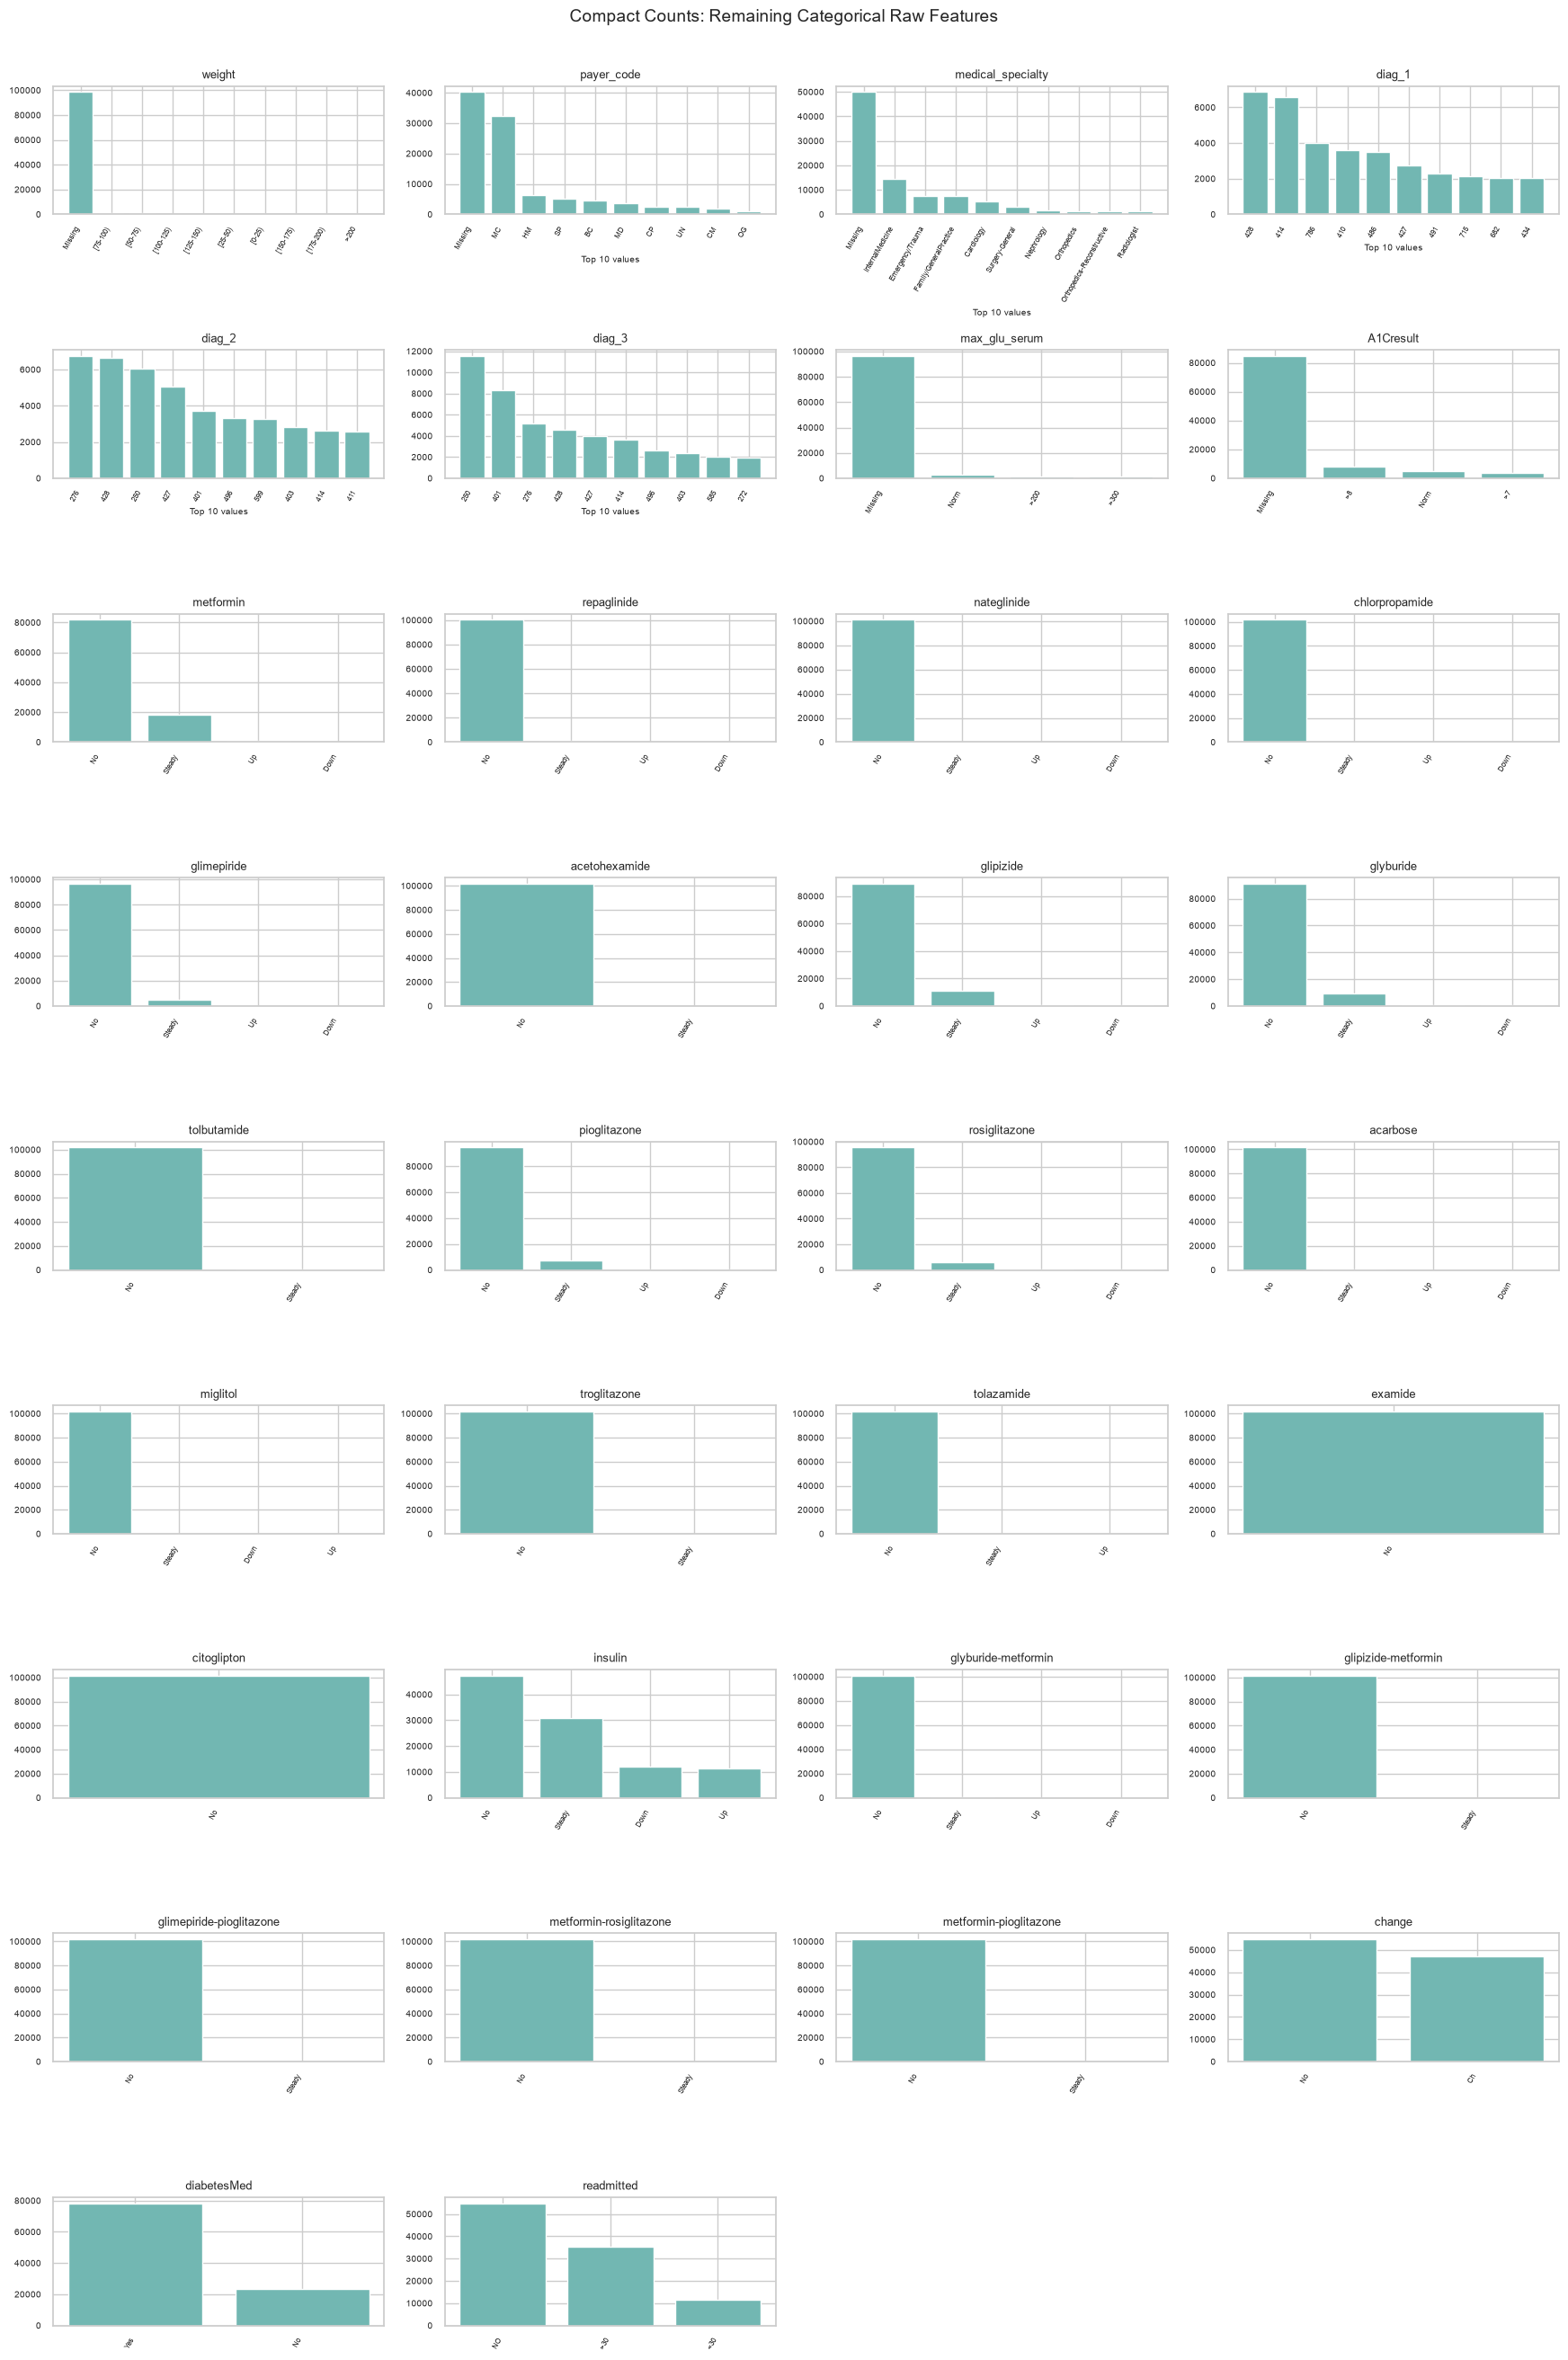

Notably skewed numeric fields (|skew| > 1): ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'num_procedures']
Near-zero-variance categorical fields (dominant value >95%): ['weight', 'repaglinide', 'nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
High-cardinality categorical fields (>20 observed values): ['medical_specialty', 'diag_1', 'diag_2', 'diag_3']


In [7]:
raw_columns = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()
detailed_univariate_features = [
    'age', 'time_in_hospital', 'num_lab_procedures', 'num_medications',
    'number_diagnoses', 'number_inpatient', 'number_outpatient',
    'number_emergency', 'race', 'gender'
]
identifier_columns = ['encounter_id', 'patient_nbr']
remaining_raw_columns = [
    column for column in raw_columns
    if column not in detailed_univariate_features + identifier_columns
]

numeric_remaining = [
    column for column in remaining_raw_columns
    if pd.api.types.is_numeric_dtype(df[column])
]
categorical_remaining = [column for column in remaining_raw_columns if column not in numeric_remaining]

print(f'Raw columns: {len(raw_columns)}')
print(f'Detailed individual plots: {len(detailed_univariate_features)}')
print(f'Identifier columns excluded from visualization: {identifier_columns}')
print(f'Numeric compact-grid columns ({len(numeric_remaining)}): {numeric_remaining}')
print(f'Categorical compact-grid columns ({len(categorical_remaining)}): {categorical_remaining}')
assert len(detailed_univariate_features) + len(identifier_columns) + len(remaining_raw_columns) == len(raw_columns)

def compact_axes(feature_names, ncols=4, height_per_row=2.8):
    nrows = int(np.ceil(len(feature_names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, height_per_row * nrows))
    return fig, np.atleast_1d(axes).ravel()

# Remaining numeric/discrete raw fields
fig, axes = compact_axes(numeric_remaining)
for ax, feature in zip(axes, numeric_remaining):
    values = df[feature].dropna()
    bins = min(30, max(5, int(values.nunique())))
    ax.hist(values, bins=bins, color='#4C78A8', edgecolor='white')
    ax.set_title(feature, fontsize=10)
    ax.tick_params(axis='both', labelsize=8)
for ax in axes[len(numeric_remaining):]:
    ax.set_visible(False)
fig.suptitle('Compact Distributions: Remaining Numeric Raw Features', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'univariate_grid_numeric.png', dpi=300, bbox_inches='tight')
plt.show()

# Remaining categorical raw fields; high-cardinality fields use their ten most common observed values.
fig, axes = compact_axes(categorical_remaining, ncols=4, height_per_row=2.9)
for ax, feature in zip(axes, categorical_remaining):
    counts = df[feature].fillna('Missing').astype(str).value_counts().head(10)
    ax.bar(range(len(counts)), counts.values, color='#72B7B2')
    ax.set_title(feature, fontsize=9)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=60, ha='right', fontsize=6)
    ax.tick_params(axis='y', labelsize=7)
    if df[feature].nunique(dropna=True) > 10:
        ax.set_xlabel('Top 10 values', fontsize=7)
for ax in axes[len(categorical_remaining):]:
    ax.set_visible(False)
fig.suptitle('Compact Counts: Remaining Categorical Raw Features', fontsize=14, y=1.005)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'univariate_grid_categorical.png', dpi=300, bbox_inches='tight')
plt.show()

# Flag distributional patterns that matter for preprocessing.
skewed_numeric = [
    feature for feature in numeric_remaining
    if abs(df[feature].dropna().skew()) > 1
]
near_zero_variance = [
    feature for feature in categorical_remaining
    if df[feature].fillna('Missing').value_counts(normalize=True).iloc[0] > 0.95
]
high_cardinality = [
    feature for feature in categorical_remaining if df[feature].nunique(dropna=True) > 20
]
print(f'Notably skewed numeric fields (|skew| > 1): {skewed_numeric}')
print(f'Near-zero-variance categorical fields (dominant value >95%): {near_zero_variance}')
print(f'High-cardinality categorical fields (>20 observed values): {high_cardinality}')

## Correlation heatmap

Interpretation: The numeric variables are mostly weakly related, with only encounter_id and patient_nbr showing a moderate correlation of about 0.51. That means the dataset is not dominated by obvious redundant numeric predictors, and the patient identifier should be excluded from the feature matrix to avoid leakage.

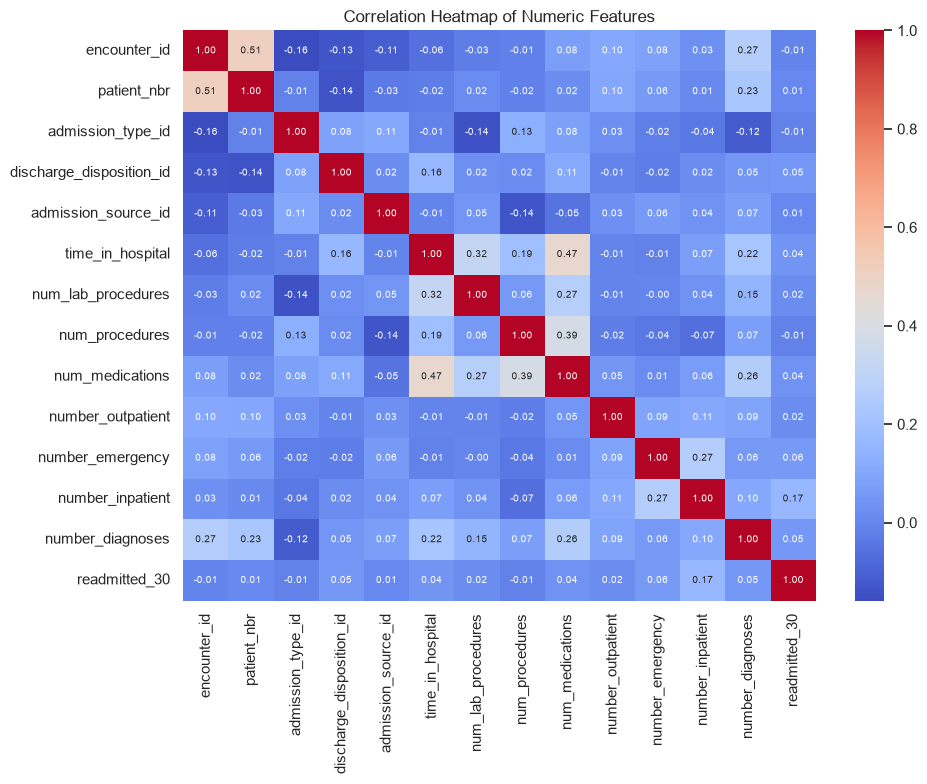

Feature pairs with |correlation| > 0.5:
encounter_id  patient_nbr    0.512028
dtype: float64


In [8]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
correlation_matrix = numeric_df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, fmt='.2f', annot_kws={'size': 7})
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_heatmap.png', dpi=300)
plt.show()

corr_pairs = correlation_matrix.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]
strong_corr = corr_pairs[corr_pairs > 0.5].drop_duplicates()
print('Feature pairs with |correlation| > 0.5:')
print(strong_corr)

## Bivariate analysis

Interpretation: The readmission-rate plots show modest but consistent differences by age, race, and gender. Older age bands have the highest rates, while the youngest group is much lower, and race differences are small but still relevant for fairness review. The duplicate-patient check is also important because repeated visits could otherwise leak information across train and test splits.

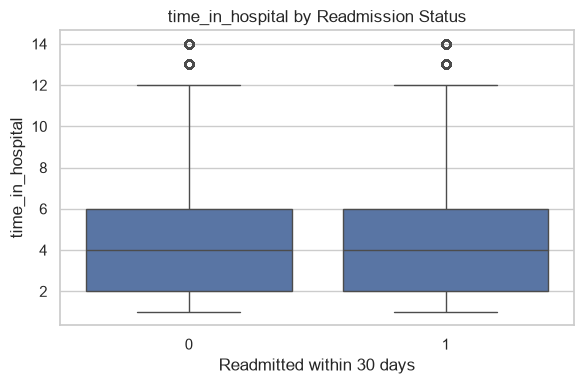

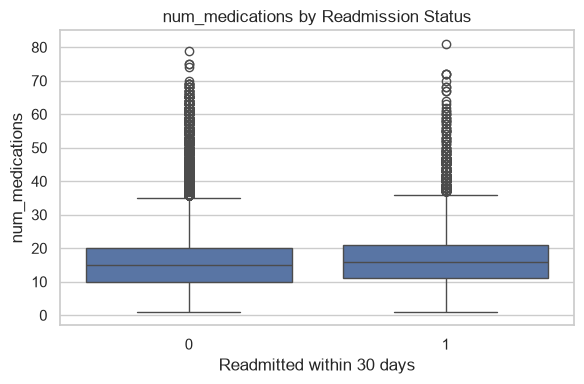

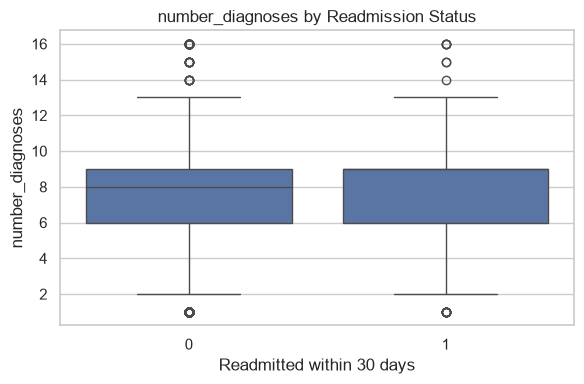

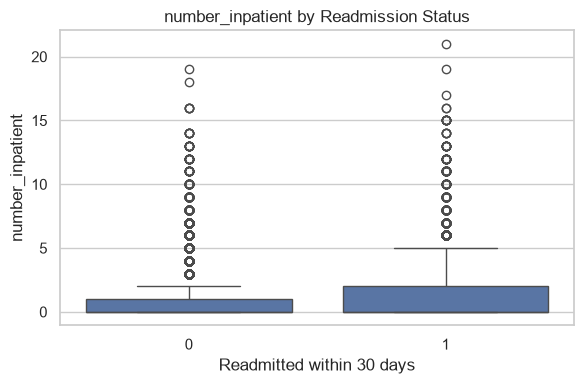

Columns with >40% missing (candidates to drop or need special handling):
['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty']



Categorical columns where one value dominates >95% (low signal):
[('weight', np.float64(96.9)), ('repaglinide', np.float64(98.5)), ('nateglinide', np.float64(99.3)), ('chlorpropamide', np.float64(99.9)), ('acetohexamide', np.float64(100.0)), ('tolbutamide', np.float64(100.0)), ('acarbose', np.float64(99.7)), ('miglitol', np.float64(100.0)), ('troglitazone', np.float64(100.0)), ('tolazamide', np.float64(100.0)), ('examide', np.float64(100.0)), ('citoglipton', np.float64(100.0)), ('glyburide-metformin', np.float64(99.3)), ('glipizide-metformin', np.float64(100.0)), ('glimepiride-pioglitazone', np.float64(100.0)), ('metformin-rosiglitazone', np.float64(100.0)), ('metformin-pioglitazone', np.float64(100.0))]

Unique patients: 71518, total encounters: 101766
Patients with multiple encounters: 16773
Encounters belonging to duplicate patients: 47021
Top repeated patient counts:
patient_nbr
88785891    40
43140906    28
88227540    23
1660293     23
23199021    23
84428613    22
23643405    2

In [9]:
if 'df' not in globals():
    raise RuntimeError('This cell requires the dataset and notebook state defined in earlier cells. Run the notebook from the top before this analysis cell.')

for feature in ['time_in_hospital', 'num_medications', 'number_diagnoses', 'number_inpatient']:
    if feature in df.columns and pd.api.types.is_numeric_dtype(df[feature]):
        plt.figure(figsize=(6, 4))
        sns.boxplot(data=df, x='readmitted_30', y=feature)
        plt.title(f'{feature} by Readmission Status')
        plt.xlabel('Readmitted within 30 days')
        plt.ylabel(feature)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f'{feature}_by_readmitted_30.png', dpi=300)
        plt.show()

if 'missing_df' not in globals():
    missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
    missing_df = missing_pct.reset_index()
    missing_df.columns = ['column', 'missing_pct']

high_missing = missing_df[missing_df['missing_pct'] > 40]['column'].tolist()
print('Columns with >40% missing (candidates to drop or need special handling):')
print(high_missing)

low_variance_cats = []
for col in df.select_dtypes(include='object').columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    if top_freq > 0.95:
        low_variance_cats.append((col, round(top_freq * 100, 1)))
print('\nCategorical columns where one value dominates >95% (low signal):')
print(low_variance_cats)

high_missing_df = missing_df[missing_df['missing_pct'] > 40][['column', 'missing_pct']].copy()
high_missing_df.to_csv(FIGURES_DIR / 'high_missing_candidates.csv', index=False)

low_variance_cats_df = pd.DataFrame(low_variance_cats, columns=['column', 'dominant_pct'])
low_variance_cats_df.to_csv(FIGURES_DIR / 'low_variance_categorical_columns.csv', index=False)

patient_counts = df['patient_nbr'].value_counts()
duplicate_patients = patient_counts[patient_counts > 1]
n_unique_patients = df['patient_nbr'].nunique()
n_encounters = len(df)
print(f'\nUnique patients: {n_unique_patients}, total encounters: {n_encounters}')
print(f'Patients with multiple encounters: {len(duplicate_patients)}')
print(f'Encounters belonging to duplicate patients: {int(duplicate_patients.sum())}')
print('Top repeated patient counts:')
print(duplicate_patients.head(10))


## Summary

The notebook has completed the data-loading, cleaning, missingness audit, target preparation, and initial exploratory analysis steps. The two most important numbers from this stage are the missing-value hotspots and the class-imbalance ratio, which will guide the preprocessing and modeling decisions in the next stage.